In [25]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [27]:
df.info()
df.dtypes
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [28]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [42]:
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"], errors="coerce"
)

In [32]:
df = df.dropna()

In [43]:
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

In [44]:
df[["account.Charges.Monthly","Cuentas_Diarias"]].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [35]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [36]:
df.describe()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7043.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098
std,0.441561,0.369074,24.571773,30.129572
min,0.000000,0.000000,0.000000,18.250000
25%,0.000000,0.000000,9.000000,35.425000
50%,0.000000,0.000000,29.000000,70.300000
75%,1.000000,0.000000,55.000000,89.875000
max,1.000000,1.000000,72.000000,118.750000


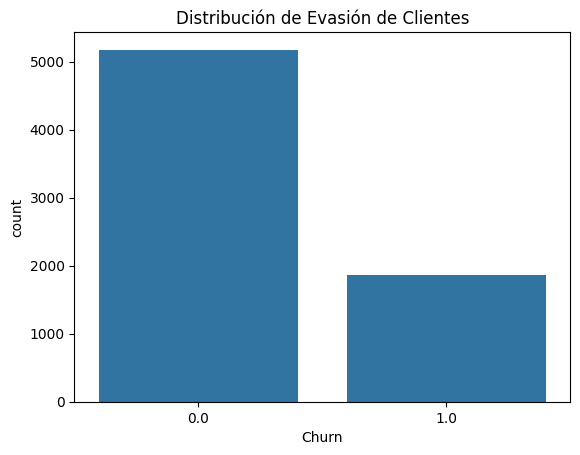

In [37]:
sns.countplot(x="Churn", data=df)

plt.title("Distribución de Evasión de Clientes")
plt.show()

In [48]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias'],
      dtype='object')

In [50]:
df.columns = df.columns.str.replace(".", "_", regex=False)

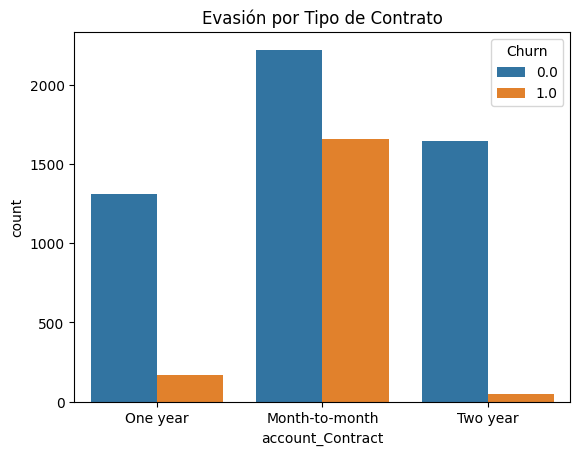

In [51]:
sns.countplot(x="account_Contract", hue="Churn", data=df)

plt.title("Evasión por Tipo de Contrato")
plt.show()

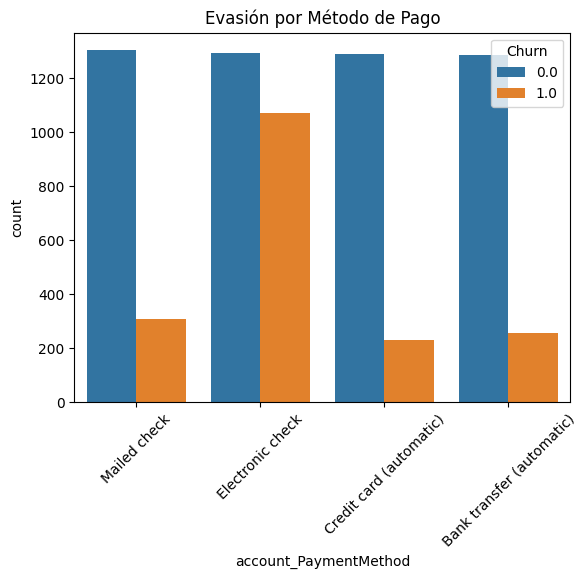

In [52]:
sns.countplot(x="account_PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=45)
plt.title("Evasión por Método de Pago")
plt.show()

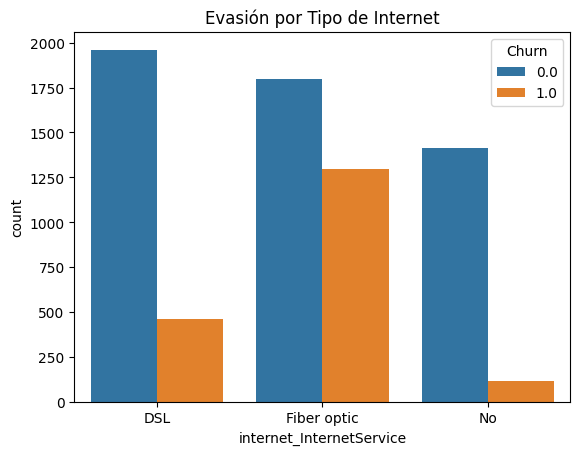

In [53]:
sns.countplot(x="internet_InternetService", hue="Churn", data=df)

plt.title("Evasión por Tipo de Internet")
plt.show()

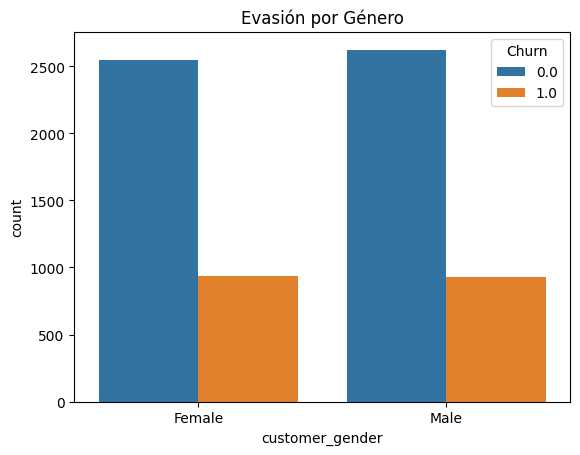

In [54]:
sns.countplot(x="customer_gender", hue="Churn", data=df)

plt.title("Evasión por Género")
plt.show()

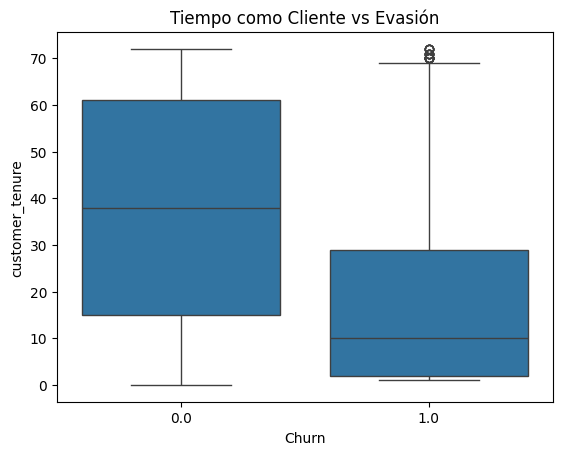

In [55]:
sns.boxplot(x="Churn", y="customer_tenure", data=df)

plt.title("Tiempo como Cliente vs Evasión")
plt.show()

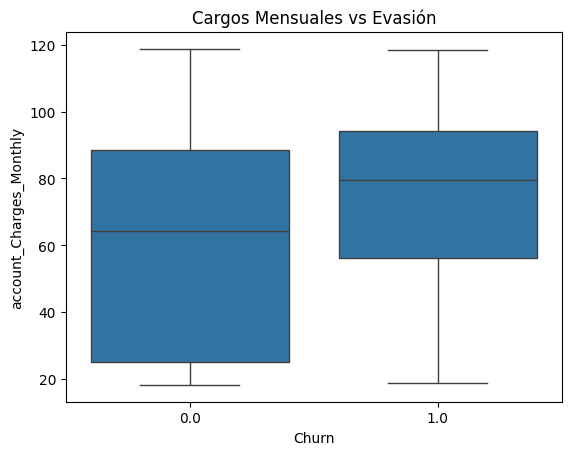

In [56]:
sns.boxplot(x="Churn", y="account_Charges_Monthly", data=df)

plt.title("Cargos Mensuales vs Evasión")
plt.show()

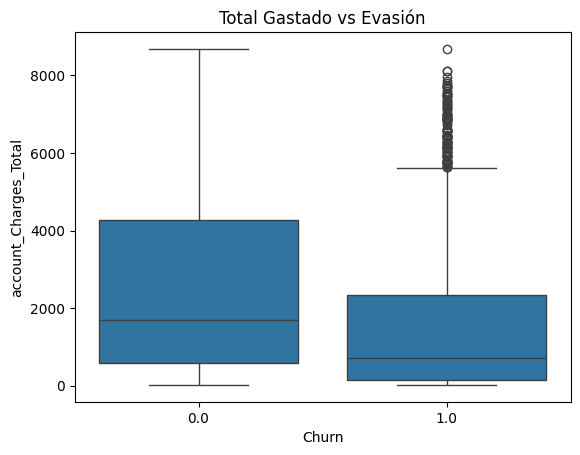

In [57]:
sns.boxplot(x="Churn", y="account_Charges_Total", data=df)

plt.title("Total Gastado vs Evasión")
plt.show()

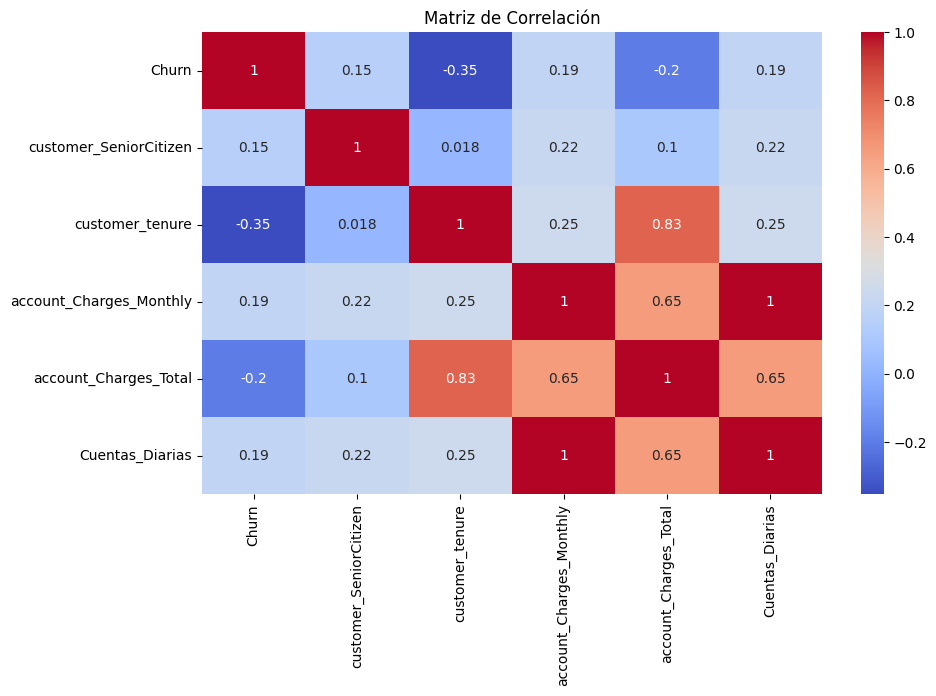

In [58]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Matriz de Correlación")
plt.show()